In [1]:
import os
import glob
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Python OK")
print("TensorFlow version:", tf.__version__)

Python OK
TensorFlow version: 2.20.0


In [2]:
DATASET_DIR = r"C:\ml\kaggle-ml-basics\data\brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0"

assert os.path.isdir(DATASET_DIR), f"Không tìm thấy thư mục dataset: {DATASET_DIR}"

print("Dataset dir:", DATASET_DIR)
print("Một số file trong thư mục gốc:")
for p in sorted(os.listdir(DATASET_DIR))[:20]:
    print(" -", p)

Dataset dir: C:\ml\kaggle-ml-basics\data\brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0
Một số file trong thư mục gốc:
 - 100001
 - 100002
 - 100003
 - 100004
 - 101001
 - 101002
 - 101003
 - 101004
 - 102001
 - 102002
 - 102003
 - 102004
 - 103001
 - 103002
 - 103003
 - 103004
 - 104001
 - 104002
 - 104003
 - 104004


In [45]:
import sys
!{sys.executable} -m pip install wfdb

In [4]:
import wfdb

quality_path = os.path.join(DATASET_DIR, "quality-hr-ann.csv")
subject_info_path = os.path.join(DATASET_DIR, "subject-info.csv")
records_path = os.path.join(DATASET_DIR, "RECORDS.txt")

quality_df = pd.read_csv(quality_path)
subject_df = pd.read_csv(subject_info_path)

print("quality_df shape:", quality_df.shape)
print("subject_df shape:", subject_df.shape)

display(quality_df.head())
display(subject_df.head())

quality_df shape: (3888, 3)
subject_df shape: (3888, 10)


,ID,Quality,HR
0,100001,1,83
1,100002,1,85
2,100003,1,81
3,100004,0,85
4,101001,1,67


,ID,Gender,Age [years],Height [cm],Weight [kg],Ear/finger,Motion,Blood pressure [mmHg],Glycaemia [mmol/l],SpO2 [%]
0,100001,F,51,NaN,58,1,0,NaN,NaN,NaN
1,100002,F,51,NaN,58,1,0,NaN,NaN,NaN
2,100003,F,51,NaN,58,1,0,NaN,NaN,NaN
3,100004,F,51,NaN,58,1,2;3,NaN,NaN,NaN
4,101001,F,54,NaN,63,1,0,NaN,NaN,NaN


In [5]:
quality_df["ID"] = quality_df["ID"].astype(str).str.zfill(6)
subject_df["ID"] = subject_df["ID"].astype(str).str.zfill(6)

quality_df["subject_id"] = quality_df["ID"].str[:3]
subject_df["subject_id"] = subject_df["ID"].str[:3]

print("Số record trong quality_df:", len(quality_df))
print("Số subject duy nhất:", quality_df["subject_id"].nunique())

display(quality_df.head())

Số record trong quality_df: 3888
Số subject duy nhất: 50


,ID,Quality,HR,subject_id
0,100001,1,83,100
1,100002,1,85,100
2,100003,1,81,100
3,100004,0,85,100
4,101001,1,67,101


In [6]:
print("Phân bố Quality:")
print(quality_df["Quality"].value_counts(dropna=False))
print()

if "HR" in quality_df.columns:
    print("Thống kê HR:")
    print(quality_df["HR"].describe())

print("\nMột vài cột trong subject-info:")
print(subject_df.columns.tolist())

Phân bố Quality:
Quality
0    3058
1     830
Name: count, dtype: int64

Thống kê HR:
count    3888.000000
mean       78.146605
std        13.329823
min        38.000000
25%        69.000000
50%        77.000000
75%        85.000000
max       161.000000
Name: HR, dtype: float64

Một vài cột trong subject-info:
['ID', 'Gender', 'Age [years]', 'Height [cm]', 'Weight [kg]', 'Ear/finger', 'Motion', 'Blood pressure [mmHg]', 'Glycaemia [mmol/l]', 'SpO2 [%]', 'subject_id']


In [7]:
df = quality_df.merge(subject_df, on=["ID", "subject_id"], how="left")

print("Merged shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Merged shape: (3888, 13)


,ID,Quality,HR,subject_id,Gender,Age [years],Height [cm],Weight [kg],Ear/finger,Motion,Blood pressure [mmHg],Glycaemia [mmol/l],SpO2 [%]
0,100001,1,83,100,F,51,NaN,58,1,0,NaN,NaN,NaN
1,100002,1,85,100,F,51,NaN,58,1,0,NaN,NaN,NaN
2,100003,1,81,100,F,51,NaN,58,1,0,NaN,NaN,NaN
3,100004,0,85,100,F,51,NaN,58,1,2;3,NaN,NaN,NaN
4,101001,1,67,101,F,54,NaN,63,1,0,NaN,NaN,NaN



Columns:
['ID', 'Quality', 'HR', 'subject_id', 'Gender', 'Age [years]', 'Height [cm]', 'Weight [kg]', 'Ear/finger', 'Motion', 'Blood pressure [mmHg]', 'Glycaemia [mmol/l]', 'SpO2 [%]']


In [15]:
def get_ppg_record_path(record_id: str):
    """
    Trả về path không kèm đuôi cho wfdb.rdrecord
    ví dụ:
    C:/.../100001/100001_PPG
    """
    record_dir = os.path.join(DATASET_DIR, record_id)
    base = os.path.join(record_dir, f"{record_id}_PPG")
    hea = base + ".hea"
    dat = base + ".dat"
    if os.path.isfile(hea) and os.path.isfile(dat):
        return base
    return None

def get_ppg_1d_signal(record):
    """
    Chuẩn hoá output của wfdb.rdrecord về vector 1D theo thời gian.

    BUT PPG có thể xuất hiện 2 layout:
    - (n_samples, n_channels)  -> lấy kênh đầu: [:, 0]
    - (1, n_samples)           -> lấy hàng đầu: [0, :]
    """
    p = np.asarray(record.p_signal, dtype=np.float32)

    if p.ndim == 1:
        return p

    if p.shape[0] >= p.shape[1]:
        return p[:, 0]
    return p[0, :]

# test nhanh
test_id = df.iloc[0]["ID"]
print("test ID:", test_id)
print("ppg path:", get_ppg_record_path(test_id))

test ID: 100001
ppg path: C:\ml\kaggle-ml-basics\data\brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0\100001\100001_PPG


In [16]:
sample_id = df.iloc[0]["ID"]
sample_path = get_ppg_record_path(sample_id)

record = wfdb.rdrecord(sample_path)
print("sample_id:", sample_id)
print("fs:", record.fs)
print("sig_name:", record.sig_name)
print("p_signal shape:", record.p_signal.shape)

ppg = get_ppg_1d_signal(record)
print("PPG length:", len(ppg))
print("First 10 samples:", ppg[:10])

sample_id: 100001
fs: 30
sig_name: ['.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0 0', '.u. 0 0 0 0

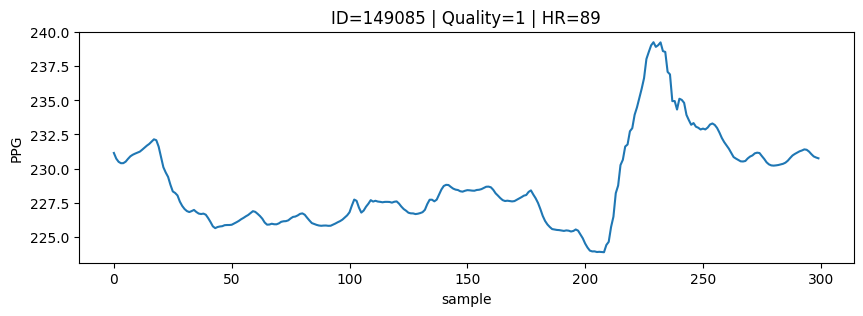

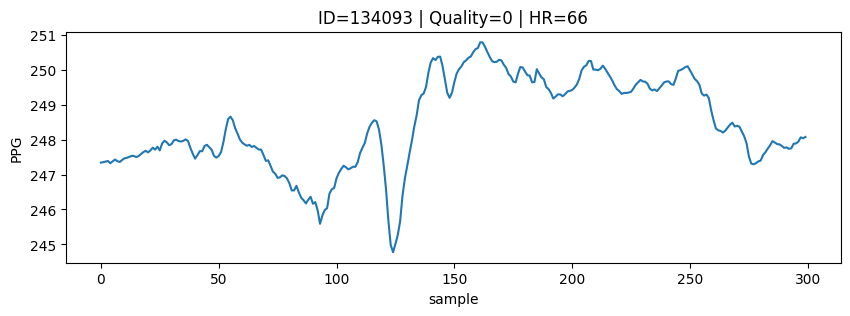

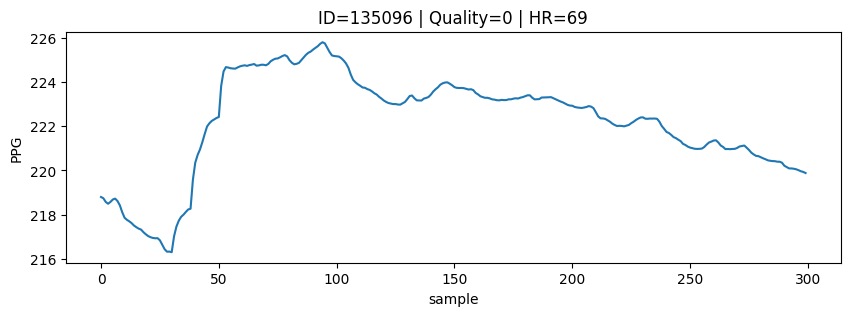

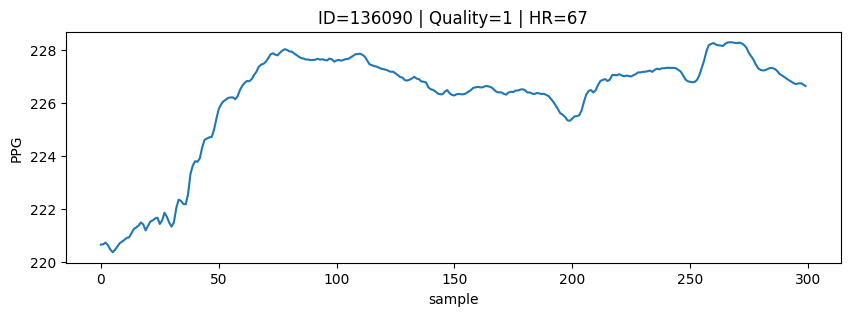

In [17]:
example_ids = df["ID"].sample(4, random_state=42).tolist()

for rid in example_ids:
    path = get_ppg_record_path(rid)
    rec = wfdb.rdrecord(path)
    sig = get_ppg_1d_signal(rec)

    plt.figure(figsize=(10, 3))
    plt.plot(sig)
    row = df[df["ID"] == rid].iloc[0]
    plt.title(f"ID={rid} | Quality={row['Quality']} | HR={row['HR']}")
    plt.xlabel("sample")
    plt.ylabel("PPG")
    plt.show()

In [18]:
def preprocess_ppg_signal(sig: np.ndarray, normalize_std: bool = False):
    sig = np.asarray(sig, dtype=np.float32)

    # loại trung bình
    sig = sig - np.mean(sig)

    if normalize_std:
        std = np.std(sig)
        if std < 1e-8:
            std = 1.0
        sig = sig / std

    return sig

In [19]:
def extract_handcrafted_features(sig: np.ndarray):
    x = np.asarray(sig, dtype=np.float32)

    dx = np.diff(x)
    ddx = np.diff(dx)

    feats = {
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
        "median": float(np.median(x)),
        "ptp": float(np.ptp(x)),  # peak-to-peak
        "q10": float(np.percentile(x, 10)),
        "q25": float(np.percentile(x, 25)),
        "q75": float(np.percentile(x, 75)),
        "q90": float(np.percentile(x, 90)),
        "energy": float(np.mean(x**2)),
        "mad": float(np.mean(np.abs(x - np.mean(x)))),
        "dx_mean": float(np.mean(dx)) if len(dx) > 0 else 0.0,
        "dx_std": float(np.std(dx)) if len(dx) > 0 else 0.0,
        "ddx_std": float(np.std(ddx)) if len(ddx) > 0 else 0.0,
        "zero_crossings": int(np.sum(np.diff(np.signbit(x)).astype(np.int32))) if len(x) > 1 else 0,
        "dx_zero_crossings": int(np.sum(np.diff(np.signbit(dx)).astype(np.int32))) if len(dx) > 1 else 0,
    }

    # skewness, kurtosis gần đúng (không cần scipy)
    x_centered = x - np.mean(x)
    s = np.std(x)
    if s < 1e-8:
        feats["skew"] = 0.0
        feats["kurtosis"] = 0.0
    else:
        feats["skew"] = float(np.mean((x_centered / s) ** 3))
        feats["kurtosis"] = float(np.mean((x_centered / s) ** 4))

    # chặn NaN/inf phòng trường hợp tín hiệu dị thường
    for k, v in feats.items():
        if isinstance(v, float) and (np.isnan(v) or np.isinf(v)):
            feats[k] = 0.0

    return feats

In [20]:
rows = []

for idx, row in df.iterrows():
    rid = row["ID"]
    ppg_path = get_ppg_record_path(rid)

    if ppg_path is None:
        continue

    try:
        rec = wfdb.rdrecord(ppg_path)
        sig = get_ppg_1d_signal(rec)
        sig = preprocess_ppg_signal(sig, normalize_std=False)
        feats = extract_handcrafted_features(sig)

        item = {
            "ID": rid,
            "subject_id": row["subject_id"],
            "Quality": int(row["Quality"]),
            "HR": float(row["HR"]),
        }

        # thêm metadata với tên cột đúng của subject-info.csv
        column_map = {
            "Gender": "Gender",
            "Age [years]": "Age",
            "Ear/finger": "Ear_finger",
            "Motion": "Motion",
        }
        for src_col, dst_col in column_map.items():
            if src_col in row.index:
                item[dst_col] = row[src_col]

        item.update(feats)
        rows.append(item)

    except Exception as e:
        print(f"Lỗi đọc record {rid}: {e}")

feature_df = pd.DataFrame(rows)
print("feature_df shape:", feature_df.shape)
display(feature_df.head())
print("\nNaN theo cột (top 10):")
display(feature_df.isna().sum().sort_values(ascending=False).head(10))

feature_df shape: (3888, 27)


,ID,subject_id,Quality,HR,Gender,Age,Ear_finger,Motion,mean,std,...,q90,energy,mad,dx_mean,dx_std,ddx_std,zero_crossings,dx_zero_crossings,skew,kurtosis
0,100001,100,1,83.0,F,51,1,0,0.000011,0.163361,...,0.230980,0.026687,0.132036,-0.000575,0.161485,0.261729,78,142,0.307042,2.695784
1,100002,100,1,85.0,F,51,1,0,-0.000006,0.220934,...,0.292632,0.048812,0.178872,-0.000718,0.161295,0.250015,58,120,0.624776,3.086865
2,100003,100,1,81.0,F,51,1,0,0.000006,0.324770,...,0.387242,0.105475,0.253955,0.001160,0.279848,0.435683,74,133,0.516718,3.440132
3,100004,100,0,85.0,F,51,1,2;3,0.000009,29.052874,...,31.457689,844.069458,21.410925,0.053685,10.110504,8.631618,31,66,1.987539,7.881327
4,101001,101,1,67.0,F,54,1,0,0.000017,0.157399,...,0.233296,0.024775,0.133791,0.000882,0.050342,0.043102,22,69,0.443293,2.133322



NaN theo cột (top 10):


ID            0
subject_id    0
Quality       0
HR            0
Gender        0
Age           0
Ear_finger    0
Motion        0
mean          0
std           0
dtype: int64

In [21]:
print("Số record sau khi đọc thành công:", len(feature_df))
print("Số subject:", feature_df["subject_id"].nunique())
print("Phân bố nhãn:")
print(feature_df["Quality"].value_counts())

display(feature_df.describe().T.head(20))

Số record sau khi đọc thành công: 3888
Số subject: 50
Phân bố nhãn:
Quality
0    3058
1     830
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Quality,3888.0,2.134774e-01,0.409815,0.000000,0.000000,0.000000e+00,0.000000,1.000000
HR,3888.0,7.814660e+01,13.329823,38.000000,69.000000,7.700000e+01,85.000000,161.000000
Age,3888.0,3.313735e+01,16.740707,19.000000,22.000000,2.300000e+01,44.000000,76.000000
Ear_finger,3888.0,4.953704e-01,0.500043,0.000000,0.000000,0.000000e+00,1.000000,1.000000
mean,3888.0,1.403491e-07,0.000010,-0.000041,-0.000005,0.000000e+00,0.000005,0.000041
std,3888.0,6.208380e+00,11.859642,0.000000,0.801662,2.073899e+00,5.428414,112.617165
min,3888.0,-1.292471e+01,23.586541,-215.968338,-12.012589,-4.553299e+00,-1.591008,0.000000
max,3888.0,1.246925e+01,25.317151,0.000000,1.570168,4.083679e+00,11.036323,226.706894
median,3888.0,-7.447286e-02,5.732019,-72.364052,-0.252369,5.270004e-03,0.378761,79.991318
ptp,3888.0,2.539395e+01,43.003696,0.000000,3.429310,9.002884e+00,24.040528,252.962860


In [22]:
groups = feature_df["subject_id"].values
y = feature_df["Quality"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(feature_df, y, groups=groups))

train_df = feature_df.iloc[train_idx].reset_index(drop=True)
test_df  = feature_df.iloc[test_idx].reset_index(drop=True)

print("Train size:", len(train_df), "subjects:", train_df["subject_id"].nunique())
print("Test size :", len(test_df),  "subjects:", test_df["subject_id"].nunique())
print("\nTrain quality:")
print(train_df["Quality"].value_counts(normalize=True))
print("\nTest quality:")
print(test_df["Quality"].value_counts(normalize=True))

Train size: 2898 subjects: 40
Test size : 990 subjects: 10

Train quality:
Quality
0    0.768806
1    0.231194
Name: proportion, dtype: float64

Test quality:
Quality
0    0.838384
1    0.161616
Name: proportion, dtype: float64


In [24]:
drop_cols = ["ID", "subject_id", "Quality", "HR"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

# tách cột numeric / categorical
X_train_raw = train_df[feature_cols].copy()
X_test_raw = test_df[feature_cols].copy()

cat_cols = X_train_raw.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numeric columns:", len(num_cols))

# one-hot encode categorical, rồi align để train/test cùng chiều
X_train_enc = pd.get_dummies(X_train_raw, columns=cat_cols, dummy_na=True)
X_test_enc = pd.get_dummies(X_test_raw, columns=cat_cols, dummy_na=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

X_train = X_train_enc.values.astype(np.float32)
y_train = train_df["Quality"].values.astype(np.int64)

X_test = X_test_enc.values.astype(np.float32)
y_test = test_df["Quality"].values.astype(np.int64)

print("MLP feature dimension:", X_train.shape[1])
print("X_train:", X_train.shape, "X_test:", X_test.shape)

Categorical columns: ['Gender', 'Motion']
Numeric columns: 21
MLP feature dimension: 34
X_train: (2898, 34) X_test: (990, 34)


In [32]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: 0.650359066427289, 1: 2.162686567164179}


In [33]:
mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        batch_size=64,
        max_iter=250,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    ))
])

sample_weight_mlp = np.array([class_weight_dict[int(cls)] for cls in y_train], dtype=np.float32)
mlp.fit(X_train, y_train, clf__sample_weight=sample_weight_mlp)

y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

print("=== MLP Classification Report ===")
print(classification_report(y_test, y_pred_mlp, digits=4))

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_mlp))
print("F1 score:", f1_score(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_mlp))

=== MLP Classification Report ===
              precision    recall  f1-score   support

           0     0.8790    0.7964    0.8357       830
           1     0.2899    0.4313    0.3467       160

    accuracy                         0.7374       990
   macro avg     0.5845    0.6138    0.5912       990
weighted avg     0.7838    0.7374    0.7566       990

Balanced accuracy: 0.6138177710843373
F1 score: 0.34673366834170855
ROC-AUC: 0.7145105421686747

Confusion matrix:
[[661 169]
 [ 91  69]]


In [34]:
TARGET_SIGNAL_LEN = 300

def load_ppg_raw_by_ids(id_list):
    arr = []
    for rid in id_list:
        ppg_path = get_ppg_record_path(rid)
        rec = wfdb.rdrecord(ppg_path)

        sig = get_ppg_1d_signal(rec)
        sig = preprocess_ppg_signal(sig)

        if len(sig) < TARGET_SIGNAL_LEN:
            sig = np.pad(sig, (0, TARGET_SIGNAL_LEN - len(sig)), mode="constant")
        elif len(sig) > TARGET_SIGNAL_LEN:
            sig = sig[:TARGET_SIGNAL_LEN]

        arr.append(sig.astype(np.float32))

    return np.stack(arr, axis=0)

X_train_raw = load_ppg_raw_by_ids(train_df["ID"].tolist())
X_test_raw  = load_ppg_raw_by_ids(test_df["ID"].tolist())

# thêm channel dimension cho Conv1D
X_train_raw = X_train_raw[..., np.newaxis]  # (N, 300, 1)
X_test_raw  = X_test_raw[..., np.newaxis]

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)

X_train_raw: (2898, 300, 1)
X_test_raw : (990, 300, 1)


In [35]:
train_groups = train_df["subject_id"].values

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
tr_idx, val_idx = next(gss_val.split(X_train_raw, y_train, groups=train_groups))

X_tr = X_train_raw[tr_idx]
y_tr = y_train[tr_idx]

X_val = X_train_raw[val_idx]
y_val = y_train[val_idx]

print("CNN train:", X_tr.shape, y_tr.shape)
print("CNN val  :", X_val.shape, y_val.shape)

CNN train: (2554, 300, 1) (2554,)
CNN val  : (344, 300, 1) (344,)


In [36]:
def build_cnn_1d(input_shape=(300, 1)):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(16, kernel_size=5, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(32, kernel_size=5, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),

        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="acc"),
            keras.metrics.AUC(name="auc")
        ]
    )
    return model

cnn1d = build_cnn_1d(input_shape=X_tr.shape[1:])
cnn1d.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 300, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 150, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 75, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 75, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

history = cnn1d.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=35,
    batch_size=64,
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.6731 - auc: 0.7908 - loss: 0.5684 - val_acc: 0.5610 - val_auc: 0.8141 - val_loss: 0.6738 - learning_rate: 0.0010
Epoch 2/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.6825 - auc: 0.7919 - loss: 0.5645 - val_acc: 0.6221 - val_auc: 0.7951 - val_loss: 0.5970 - learning_rate: 0.0010
Epoch 3/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.6915 - auc: 0.8027 - loss: 0.5538 - val_acc: 0.5843 - val_auc: 0.8215 - val_loss: 0.6287 - learning_rate: 0.0010
Epoch 4/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.6793 - auc: 0.8093 - loss: 0.5477 - val_acc: 0.6366 - val_auc: 0.8144 - val_loss: 0.5623 - learning_rate: 0.0010
Epoch 5/35
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.6887 - auc: 0.8186 - loss: 0.5424 - val_acc: 0.6860 - val_auc: 0.8170 - val_loss: 0.5147 - learning_rate: 0.0010
Epoch 6/35
38/40 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.7247 - auc: 0.8055 - loss: 0.5561
Epoch 6: ReduceLROnPlateau reducing learn

In [42]:
CNN_THRESHOLD = 0.5

y_prob_cnn = cnn1d.predict(X_test_raw, verbose=0).ravel()
y_pred_cnn = (y_prob_cnn >= CNN_THRESHOLD).astype(np.int64)

print(f"Threshold: {CNN_THRESHOLD:.2f}")
print("=== CNN 1D Classification Report ===")
print(classification_report(y_test, y_pred_cnn, digits=4))

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_cnn))
print("Recall lớp 1:", recall_score(y_test, y_pred_cnn, pos_label=1, zero_division=0))
print("Precision lớp 1:", precision_score(y_test, y_pred_cnn, pos_label=1, zero_division=0))
print("F1 lớp 1:", f1_score(y_test, y_pred_cnn, pos_label=1, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cnn))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_cnn))

Threshold: 0.50
=== CNN 1D Classification Report ===
              precision    recall  f1-score   support

           0     0.9160    0.6566    0.7649       830
           1     0.2785    0.6875    0.3964       160

    accuracy                         0.6616       990
   macro avg     0.5972    0.6721    0.5807       990
weighted avg     0.8129    0.6616    0.7054       990

Balanced accuracy: 0.6720632530120482
Recall lớp 1: 0.6875
Precision lớp 1: 0.27848101265822783
F1 lớp 1: 0.3963963963963964
ROC-AUC: 0.7387876506024098

Confusion matrix:
[[545 285]
 [ 50 110]]


In [43]:
# --- Diagnostics: dataset difficulty & split sanity ---
from sklearn.metrics import accuracy_score

print("=== Split sanity ===")
train_subjects = set(train_df["subject_id"].astype(str))
test_subjects = set(test_df["subject_id"].astype(str))
print("Subject overlap train/test:", len(train_subjects.intersection(test_subjects)))

print("\n=== Class balance ===")
train_pos = float(np.mean(y_train))
test_pos = float(np.mean(y_test))
print(f"Train positive rate (Quality=1): {train_pos:.4f}")
print(f"Test  positive rate (Quality=1): {test_pos:.4f}")

print("\n=== Dummy baselines on TEST ===")
y_pred_all0 = np.zeros_like(y_test)
y_pred_all1 = np.ones_like(y_test)
print("All-0 accuracy:", accuracy_score(y_test, y_pred_all0))
print("All-0 balanced_accuracy:", balanced_accuracy_score(y_test, y_pred_all0))
print("All-0 F1(1):", f1_score(y_test, y_pred_all0, pos_label=1, zero_division=0))
print("All-1 accuracy:", accuracy_score(y_test, y_pred_all1))
print("All-1 balanced_accuracy:", balanced_accuracy_score(y_test, y_pred_all1))
print("All-1 F1(1):", f1_score(y_test, y_pred_all1, pos_label=1, zero_division=0))

print("\n=== Per-subject positive ratio (train/test) ===")
train_subj_pos = train_df.groupby("subject_id")["Quality"].mean().describe()
test_subj_pos = test_df.groupby("subject_id")["Quality"].mean().describe()
print("Train subject-level positive ratio stats:")
print(train_subj_pos)
print("\nTest subject-level positive ratio stats:")
print(test_subj_pos)

print("\n=== Missing / constant feature checks ===")
num_part = train_df.select_dtypes(include=[np.number]).drop(columns=["Quality"], errors="ignore")
const_cols = [c for c in num_part.columns if num_part[c].nunique(dropna=False) <= 1]
print("Constant numeric columns:", const_cols)

nan_rate = train_df.isna().mean().sort_values(ascending=False).head(10)
print("Top NaN rate columns in train:")
print(nan_rate)

print("\n=== Quick interpretation hints ===")
print("- If all-0 accuracy is high but balanced_accuracy=0.5, class imbalance is dominating accuracy.")
print("- If subject overlap is 0, split is leakage-safe (good).")
print("- Wide per-subject positive-ratio spread means domain shift across subjects (hard generalization).")

=== Split sanity ===
Subject overlap train/test: 0

=== Class balance ===
Train positive rate (Quality=1): 0.2312
Test  positive rate (Quality=1): 0.1616

=== Dummy baselines on TEST ===
All-0 accuracy: 0.8383838383838383
All-0 balanced_accuracy: 0.5
All-0 F1(1): 0.0
All-1 accuracy: 0.16161616161616163
All-1 balanced_accuracy: 0.5
All-1 F1(1): 0.2782608695652174

=== Per-subject positive ratio (train/test) ===
Train subject-level positive ratio stats:
count    40.000000
mean      0.377575
std       0.305541
min       0.009259
25%       0.101852
50%       0.236111
75%       0.750000
max       1.000000
Name: Quality, dtype: float64

Test subject-level positive ratio stats:
count    10.000000
mean      0.155556
std       0.114540
min       0.027778
25%       0.062500
50%       0.125000
75%       0.245370
max       0.370370
Name: Quality, dtype: float64

=== Missing / constant feature checks ===
Constant numeric columns: []
Top NaN rate columns in train:
ID            0.0
subject_id    0.0

In [44]:
# --- Diagnostics: GroupKFold stability check on handcrafted features ---
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier

cv_drop_cols = ["ID", "subject_id", "Quality", "HR"]
cv_feature_cols = [c for c in feature_df.columns if c not in cv_drop_cols]

X_cv_raw = feature_df[cv_feature_cols].copy()
y_cv = feature_df["Quality"].values.astype(np.int64)
groups_cv = feature_df["subject_id"].values

cv_cat_cols = X_cv_raw.select_dtypes(include=["object", "string", "category"]).columns.tolist()
X_cv_enc = pd.get_dummies(X_cv_raw, columns=cv_cat_cols, dummy_na=True).astype(np.float32)

gkf = GroupKFold(n_splits=5)
rows_cv = []
for fold, (tr, te) in enumerate(gkf.split(X_cv_enc, y_cv, groups=groups_cv), start=1):
    Xtr, Xte = X_cv_enc.iloc[tr], X_cv_enc.iloc[te]
    ytr, yte = y_cv[tr], y_cv[te]

    clf = RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42 + fold,
    )
    clf.fit(Xtr, ytr)
    prob = clf.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.5).astype(np.int64)

    rows_cv.append({
        "fold": fold,
        "test_pos_rate": float(np.mean(yte)),
        "balanced_acc": float(balanced_accuracy_score(yte, pred)),
        "f1_1": float(f1_score(yte, pred, pos_label=1, zero_division=0)),
        "recall1": float(recall_score(yte, pred, pos_label=1, zero_division=0)),
        "precision1": float(precision_score(yte, pred, pos_label=1, zero_division=0)),
        "roc_auc": float(roc_auc_score(yte, prob)),
    })

cv_df = pd.DataFrame(rows_cv)
print("=== GroupKFold (5-fold) diagnostic ===")
display(cv_df)
print("\nMean metrics:")
print(cv_df[["balanced_acc", "f1_1", "recall1", "precision1", "roc_auc"]].mean())
print("\nStd metrics:")
print(cv_df[["balanced_acc", "f1_1", "recall1", "precision1", "roc_auc"]].std())

=== GroupKFold (5-fold) diagnostic ===


,fold,test_pos_rate,balanced_acc,f1_1,recall1,precision1,roc_auc
0,1,0.219298,0.615249,0.393443,0.342857,0.461538,0.799486
1,2,0.097744,0.577083,0.223176,0.333333,0.167742,0.695513
2,3,0.201571,0.636768,0.423077,0.357143,0.518868,0.798291
3,4,0.344241,0.625623,0.461538,0.365019,0.627451,0.777775
4,5,0.209424,0.596854,0.341880,0.250000,0.540541,0.696249



Mean metrics:
balanced_acc    0.610316
f1_1            0.368623
recall1         0.329670
precision1      0.463228
roc_auc         0.753463
dtype: float64

Std metrics:
balanced_acc    0.023685
f1_1            0.092310
recall1         0.046203
precision1      0.175611
roc_auc         0.053269
dtype: float64
